In [1]:
import os
import sys
import json
import glob
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
sys.path.append("..")
from process.ifc_analysis_utils import *

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
root = Path.cwd().parent
mixs = ["mix_37_235", "mix_55_532"]
metrics = ["F1_score", "G_mean"]

all_results = build_all_results(data_root= root/"experiments")
artifacts_table = build_artifacts_path_table(data_root=root/"experiments")

orig_table = build_original_data_path_table(data_root=root/"experiments")
orig_table = add_pos_paths(orig_table, pos_label=1)

✅ build_all_results 完成: 共11625行, baseline=3255, none=930, self_loop=7440


In [ ]:
from utils.common import load_json, DATASETS, CLASSIFIERS
from process.ifc_tables import DATASET_ABBREV

all_datasets = DATASETS
num_datasets = ['breast_cancer_coimbra', 'PIMA_diabetes']
cat_datasets = ['TCGA_InfoWithGrade', 'Thyroid_Diff','diabetes_risk_prediction']
mixed_datasets = ['framingham', 'hepatitis']

my_datasets = all_datasets
my_classifiers = CLASSIFIERS

## 1. 分类结果展示

In [12]:
raw_table = build_raw_reference_table(all_results)

vae_only_summary = summarize_method_stats(all_results, "none_noft")   # 你要的独立汇总

extra_rows = [
    ("VAE-only", "none_noft", None, None),  
    #("VAE+FT",     "none_ft",   None, None),
    ("IFC",       "smote_ft",  "mix_55_532", 2),
]
main_table = build_comparison_table(all_results, extra_rows, mark_close_calls=False)

In [10]:
print(raw_table)

BCC & .70 $\pm$ .08 & .67 $\pm$ .08 & .56 $\pm$ .19 & .50 $\pm$ .13 & .73 $\pm$ .05 & .70 $\pm$ .08 \\
PIMA & .67 $\pm$ .04 & .74 $\pm$ .03 & .57 $\pm$ .09 & .66 $\pm$ .07 & .63 $\pm$ .05 & .71 $\pm$ .04 \\
TCGA & .86 $\pm$ .03 & .88 $\pm$ .03 & .83 $\pm$ .02 & .86 $\pm$ .02 & .85 $\pm$ .02 & .87 $\pm$ .02 \\
THY & .91 $\pm$ .03 & .94 $\pm$ .03 & .81 $\pm$ .08 & .85 $\pm$ .07 & .93 $\pm$ .04 & .94 $\pm$ .04 \\
DRP & .93 $\pm$ .03 & .92 $\pm$ .03 & .92 $\pm$ .03 & .90 $\pm$ .05 & .94 $\pm$ .02 & .92 $\pm$ .02 \\
FRM & .38 $\pm$ .02 & .67 $\pm$ .02 & .06 $\pm$ .05 & .15 $\pm$ .11 & .06 $\pm$ .03 & .17 $\pm$ .05 \\
HEP & .59 $\pm$ .11 & .75 $\pm$ .09 & .28 $\pm$ .22 & .39 $\pm$ .24 & .44 $\pm$ .14 & .58 $\pm$ .12 \\


In [13]:
print(main_table)

BCC & CTGAN & .60 $\pm$ .13 & .61 $\pm$ .10 & .69 $\pm$ .08 & .36 $\pm$ .21 & .76 $\pm$ .04 & .68 $\pm$ .07 \\
 & ForestDiff & .62 $\pm$ .10 & .61 $\pm$ .09 & \underline{.70 $\pm$ .05} & .34 $\pm$ .20 & .73 $\pm$ .05 & .66 $\pm$ .07 \\
 & SMOTE & \textbf{.70 $\pm$ .07} & .67 $\pm$ .08 & .69 $\pm$ .07 & .42 $\pm$ .17 & \underline{.78 $\pm$ .06} & .70 $\pm$ .09 \\
 & TabDDPM & .66 $\pm$ .08 & .65 $\pm$ .08 & .69 $\pm$ .06 & .40 $\pm$ .18 & .75 $\pm$ .07 & .67 $\pm$ .10 \\
 & TabKDE & .70 $\pm$ .08 & \textbf{.68 $\pm$ .07} & .69 $\pm$ .06 & .40 $\pm$ .18 & .75 $\pm$ .05 & .67 $\pm$ .07 \\
 & TVAE & .69 $\pm$ .07 & .67 $\pm$ .07 & .69 $\pm$ .06 & \underline{.48 $\pm$ .18} & \textbf{.78 $\pm$ .07} & .70 $\pm$ .10 \\
 & VAE-only & \underline{.70 $\pm$ .08} & \underline{.67 $\pm$ .09} & .69 $\pm$ .08 & \textbf{.50 $\pm$ .16} & .77 $\pm$ .07 & \textbf{.71 $\pm$ .09} \\
 & IFC & .69 $\pm$ .08 & .67 $\pm$ .08 & \textbf{.70 $\pm$ .07} & .48 $\pm$ .17 & .77 $\pm$ .06 & \underline{.71 $\pm$ .09} \\

## 2. 消融和敏感性分析

In [ ]:
# A. 统计和显著分析
for mix in mixs:
    for metric in metrics:
        print(f"Results of {mix}, in metric {metric} in run_main_ablation:")
        res_A = run_main_ablation(all_results, metric=metric, mix_ratio=mix, datasets=my_datasets, classifiers=my_classifiers)
        print(res_A['cross_rank'])
        print(f"omnibus_stat: {res_A['omnibus_stat']}, omnibus_p: {res_A['omnibus_p']}")
        display(res_A['nemenyi'])

In [ ]:
# B. Stage-depth消融(2 vs 3)
for mix in mixs:
    for metric in metrics:
        print(f"Results of {mix}, in metric {metric}")
        view = select_mix_ratio_view(all_results, mix)
        res_B = paired_test(view, metric=metric, compare_col="stage_depth", 
                            level_a=2, level_b=3, datasets=my_datasets, classifiers=my_classifiers)
        display(res_B["summary"])
        print(f"overall_stat: {res_B['overall_stat']}, overall_p: {res_B['overall_p']}")

In [ ]:
for mix in mixs:
    for metric in metrics:
        view = select_mix_ratio_view(all_results, mix_ratio=mix)
        res_G = paired_test(view, metric=metric, compare_col="stage_depth", 
                            level_a=2, level_b=3, datasets=my_datasets, classifiers=my_classifiers)
        res_G["block_results"]["diff"].describe()
        print(mix, metric, ((res_G["block_results"]["diff"] > 0).sum(), (res_G["block_results"]["diff"] < 0).sum()))

In [ ]:
# C. Mix_ratio敏感性
for metric in metrics:
    for stage_depth in [2, 3]:
        print(f"mix_ratio 敏感性分析， {metric}指标， stage_depth: {stage_depth}")
        res_C = paired_test(all_results, metric=metric, compare_col="mix_ratio", 
                            level_a="mix_37_235", level_b="mix_55_532",
                            fixed_filters={"stage_depth": stage_depth}, 
                            datasets=my_datasets, classifiers=my_classifiers)
        display(res_C["summary"])

In [ ]:
# D. smote自循环深度趋势(1→2→3)

def to_dataframe(res):
    rows = []
    for cfg, vals in res.items():
        rows.append({
            'config': cfg,
            'd1_mean': vals['means']['d1'],
            'd2_mean': vals['means']['d2'],
            'd3_mean': vals['means']['d3'], 
            'n_blocks': vals['n_blocks'],
            'p_increasing': vals['p_increasing'],
            'p_decreasing': vals['p_decreasing'],
        })
    df_res = pd.DataFrame(rows)
    return df_res

for mix in mixs:
    for metric in metrics:
        print(f"smote 自循环深度趋势分析，{mix}, {metric}")
        res_D = smote_depth_trend(all_results, metric=metric, mix_ratio=mix, 
                                  datasets=my_datasets, classifiers=my_classifiers)
        display(to_dataframe(res_D))

## 3. TSNE 可视化

In [ ]:
from utils.common import load_json
from process.visualization import *


dataset = "framingham"
seed, fold = pick_representative_fold(all_results, dataset)
orig_row = orig_table[(orig_table["Dataset"]==dataset) & (orig_table["Seed"]==seed) & (orig_table["Fold"]==fold)].iloc[0]

datasets_info = load_json(root / "data/datasets_info.json")

numerical_cols = datasets_info[dataset]["numerical"]
categorical_cols = datasets_info[dataset]["categorical"]

feature_cols = numerical_cols + categorical_cols
X_train_real = pd.read_parquet(orig_row["X_train_path"])
preprocessor = build_preprocessor(X_train_real, numerical_cols, categorical_cols)
real_df = pd.read_parquet(orig_row["X_train_pos_path"])

group_specs = [
    ("VAE-only", load_synthetic_stage(artifacts_table, dataset, seed, fold, "none_noft", stage="v0")),
    ("VAE + FT", load_synthetic_stage(artifacts_table, dataset, seed, fold, "none_ft", stage="__all_clusters__")),
    ("Self-Circulating v1", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v1")),
    ("Self-Circulating v2", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v2")),
    ("Self-Circulating v3", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "v3")),
    ("IFC (SMOTE_FT)", load_synthetic_stage(artifacts_table, dataset, seed, fold, "smote_ft", "mix_55_532", 3, "__fidelity__")),
] + [
    (m, load_synthetic_stage(artifacts_table, dataset, seed, fold, m, stage="__fidelity__"))
    for m in ["smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde"]
]

In [ ]:
combined = build_combined_embedding(real_df, group_specs, feature_cols, preprocessor)


fig_evo = render_subplot_grid(
    combined, labels=["VAE-only", "VAE + FT", "Self-Circulating v1", 
                      "Self-Circulating v2", "Self-Circulating v3", "IFC (SMOTE_FT)"],
    show_labels=["VAE-only", "VAE + FT", "Self-Circulating v1", 
                 "Self-Circulating v2", "Self-Circulating v3", "IFC (SMOTE_FT)"],)

fig_base = render_subplot_grid(
    combined, labels=["smote", "ctgan", "tvae", "forestdiffusion", "tabddpm", "tabkde"], #, "IFC (final)"
    show_labels=["SMOTE", "CTGAN", "TVAE", "ForestDiffusion", "TabDDPM", "TabKDE"],)

fig_evo.savefig(f'{dataset}_ifc_evo_tsne.pdf', bbox_inches='tight')
fig_base.savefig(f'{dataset}_base_tsne.pdf', bbox_inches='tight')

## 4. Kendall 可视化

In [ ]:
from process.visualization import plot_correlation_grid, plot_correlation_deviation_grid, correlation_deviation_summary


fig1 = plot_correlation_grid(real_df, group_specs, numerical_cols, categorical_cols)
fig2 = plot_correlation_deviation_grid(real_df, group_specs, numerical_cols, categorical_cols)
fig2.savefig(root/'results/pictures'/f'{dataset}_kendall_deviation_grid.pdf')
corr_summary = correlation_deviation_summary(real_df, group_specs, numerical_cols, categorical_cols)

## 5. 训练数据分布斜度和多峰检测等

['breast_cancer_coimbra' 'PIMA_diabetes' 'TCGA_InfoWithGrade'
 'Thyroid_Diff' 'diabetes_risk_prediction' 'framingham' 'hepatitis']


,mean,std
Method,,
TabKDE,0.060418,0.045272
TabDDPM,0.062168,0.042376
CTGAN,0.066220,0.020320
TVAE,0.085566,0.036497
IFC (final),0.100357,0.059734
SMOTE,0.122938,0.070199
ForestDiff,0.198524,0.110086


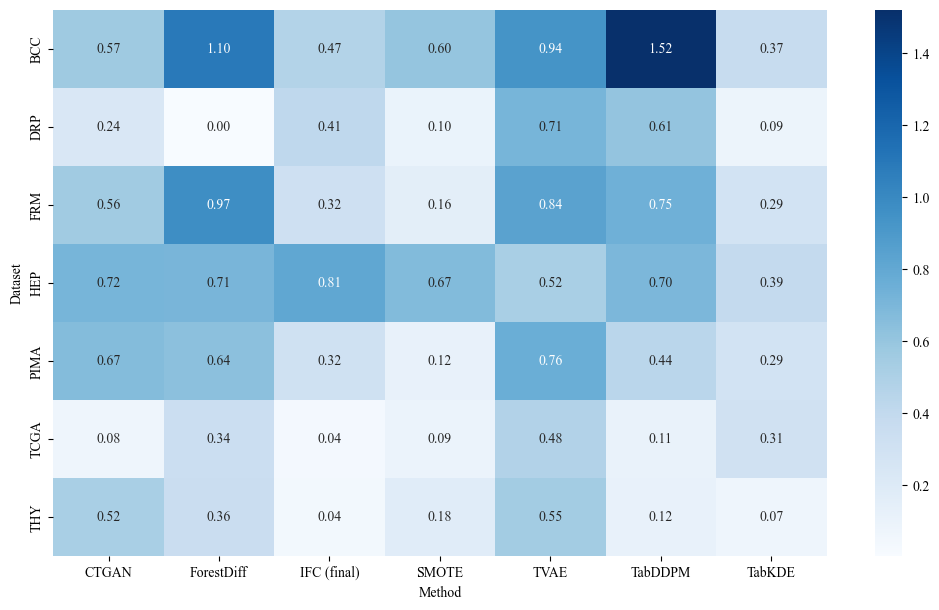

In [10]:
from process.distribution import build_fidelity_summary, plot_fidelity_heatmap, summarize_across_datasets


methods_to_show = {
    "IFC (final)": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 2, "stage": "__fidelity__"},
    "SMOTE": {"method": "smote", "stage": "__fidelity__"},
    "CTGAN": {"method": "ctgan", "stage": "__fidelity__"},
    "TVAE": {"method": "tvae", "stage": "__fidelity__"},
    "ForestDiff": {"method": "forestdiffusion", "stage": "__fidelity__"},
    "TabDDPM": {"method": "tabddpm", "stage": "__fidelity__"},
    "TabKDE": {"method": "tabkde", "stage": "__fidelity__"},
}

datasets_info = load_json(root / "data/datasets_info.json")

fidelity_summary = build_fidelity_summary(all_results, orig_table, artifacts_table, DATASETS, methods_to_show,
                                           datasets_info)

print(fidelity_summary["Dataset"].unique())
mean_abs_skew_dev = plot_fidelity_heatmap(fidelity_summary, "mean_abs_skew_dev",dataset_map=DATASET_ABBREV)
mean_abs_skew_dev.savefig(root/'results/pictures/mean_abs_skew_dev.pdf')
summarize_across_datasets(fidelity_summary, "mean_js_divergence")

### 5.1 训练数据分布统计

,mean,std
Method,,
TabKDE,0.3034,0.164076
IFC (final),0.5162,0.500368
SMOTE,0.5214,0.554238
CTGAN,0.7066,0.273337
TVAE,0.9126,0.255087
ForestDiff,0.9546,0.476001
TabDDPM,1.0080,0.660368


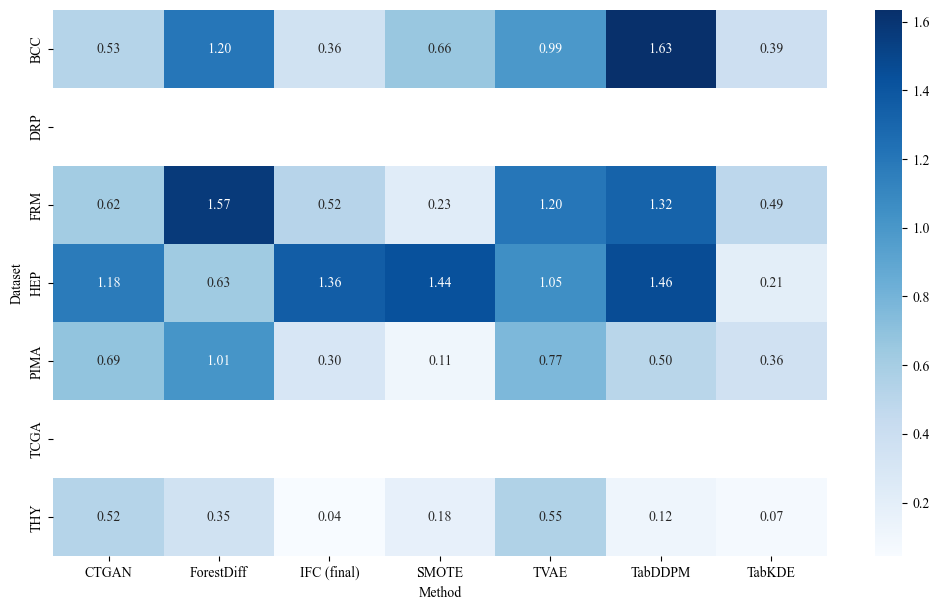

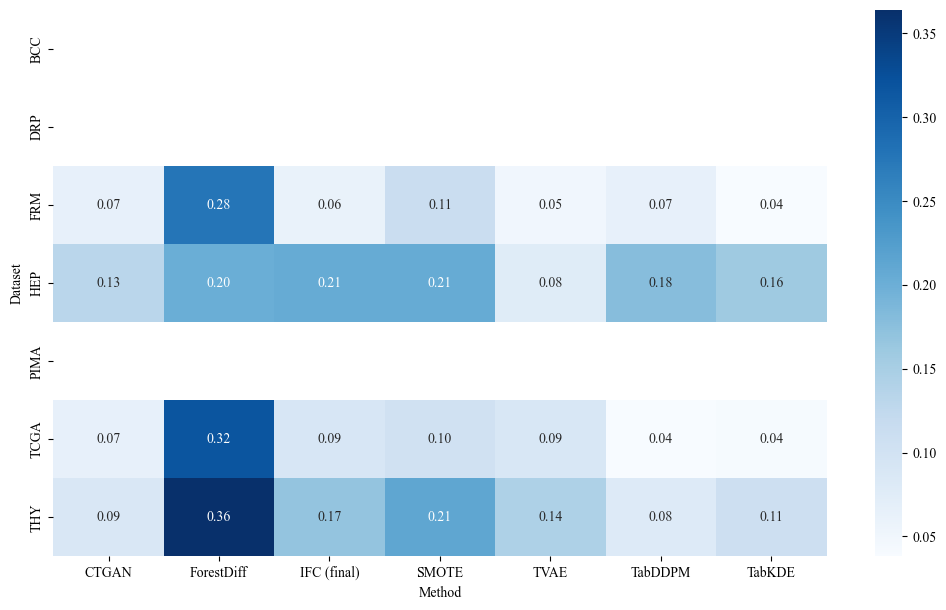

In [ ]:
from process.distribution import build_mitigation_summary_all_datasets


methods_to_show = {   # 和你上一轮fidelity_summary里的定义完全一样,直接复用
    "IFC (final)": {"method": "smote_ft", "mix_ratio": "mix_55_532", "stage_depth": 2, "stage": "__fidelity__"},
    "SMOTE": {"method": "smote", "stage": "__fidelity__"},
    "CTGAN": {"method": "ctgan", "stage": "__fidelity__"},
    "TVAE": {"method": "tvae", "stage": "__fidelity__"},
    "ForestDiff": {"method": "forestdiffusion", "stage": "__fidelity__"},
    "TabDDPM": {"method": "tabddpm", "stage": "__fidelity__"},
    "TabKDE": {"method": "tabkde", "stage": "__fidelity__"},
}
numerical_cols_map = {name: info['numerical'] for name, info in datasets_info.items()} 
categorical_cols_map = {name: info['categorical'] for name, info in datasets_info.items()} 
mitigation_all = build_mitigation_summary_all_datasets(
    all_results, orig_table, artifacts_table, DATASETS, methods_to_show,
    numerical_cols_map, categorical_cols_map,
)

# 复用上一轮的热力图/排名函数,只是换了value_col
mean_skew_dev_on_flagged = plot_fidelity_heatmap(
    mitigation_all, "mean_skew_dev_on_flagged", dataset_map=DATASET_ABBREV)
mean_js_on_flagged_categorical = plot_fidelity_heatmap(
    mitigation_all, "mean_js_on_flagged_categorical", dataset_map=DATASET_ABBREV)

mean_skew_dev_on_flagged.savefig(root / 'results/pictures/mean_skew_dev_on_flagged.pdf')
mean_js_on_flagged_categorical.savefig(root / 'results/pictures/mean_js_on_flagged_categorical.pdf')

summarize_across_datasets(mitigation_all, "mean_skew_dev_on_flagged")   # IFC vs 6个baseline的跨数据集排名